<a href="https://colab.research.google.com/github/Glaze0/Assignment/blob/main/vector_databases_under_the_hood.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### From Previous Class

In [ ]:
# Install necessary libraries: sentence-transformers for embeddings, scikit-learn for PCA and KMeans, matplotlib for plotting, and rank_bm25 for keyword search.
%pip install -q "sentence-transformers>=3.0" scikit-learn matplotlib rank_bm25

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 447, in run
    conflicts = self._determine_conflicts(to_install)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 578, in _determine_conflicts
    return check_install_conflicts(to_install)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/operations/check.py", line 101, in check_install_conflicts
    package_set, _ = create_package_set_from_installed()
              

KeyboardInterrupt: 

In [ ]:
# Import the SentenceTransformer model.
from sentence_transformers import SentenceTransformer

# Load a pre-trained SentenceTransformer model (all-MiniLM-L6-v2).
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")   # 22M params, downloads once

# Encode a sample sentence into a vector embedding.
vec = model.encode("I love pizza")

# Print the type, shape, and first 10 numbers of the generated vector.
print("type  :", type(vec))
print("shape :", vec.shape)
print("first 10 numbers:\n", vec[:10])

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

type  : <class 'numpy.ndarray'>
shape : (384,)
first 10 numbers:
 [-0.099  0.034  0.01   0.053 -0.08   0.003  0.083  0.034  0.045 -0.066]


### Output Explanation

This cell demonstrates the basic usage of the `SentenceTransformer` model to encode a piece of text into a vector embedding. The output shows:

*   **`type : <class 'numpy.ndarray'>`**: The embedding is stored as a NumPy array.
*   **`shape : (384,)`**: The vector has 384 dimensions. This is characteristic of the `all-MiniLM-L6-v2` model used.
*   **`first 10 numbers:`**: Displays the first 10 floating-point numbers of the generated embedding vector. These values are the numerical representation of the input text in the embedding space.

In [ ]:
# Define a list of movies with their titles and plot summaries.
movies = [
    ("The Matrix", "A hacker discovers reality is a simulation and joins a rebellion against machines."),
    ("Inception", "A thief enters people's dreams to plant an idea in a target's mind."),
    ("Interstellar", "Astronauts travel through a wormhole to find a new home for humanity."),
    ("Blade Runner", "A detective hunts synthetic humans in a rain-soaked future city."),
    ("Arrival", "A linguist tries to communicate with alien visitors and perceives time differently."),
    ("Jurassic Park", "Scientists clone dinosaurs for a theme park that goes catastrophically wrong."),
    ("Jaws", "A small coastal town is terrorised by a giant great white shark."),
    ("Alien", "The crew of a spaceship is hunted by a deadly creature they brought aboard."),
    ("The Shining", "A writer slowly loses his mind while caretaking an isolated winter hotel."),
    ("Get Out", "A young man visits his girlfriend's family and uncovers a sinister secret."),
    ("Parasite", "A poor family schemes their way into working for a wealthy household."),
    ("The Godfather", "The aging patriarch of a crime dynasty hands control to his reluctant son."),
    ("Goodfellas", "A young man rises through the ranks of the mob and eventually turns informant."),
    ("Heat", "A career criminal and an obsessive detective circle each other in Los Angeles."),
    ("The Dark Knight", "A masked vigilante faces an anarchic criminal terrorising the city."),
    ("Spider-Man", "A teenager gains superpowers from a spider bite and learns responsibility."),
    ("Iron Man", "An arms manufacturer builds a powered suit and becomes a hero."),
    ("Mad Max: Fury Road", "Survivors flee a tyrant across a desert wasteland in armoured vehicles."),
    ("Die Hard", "An off-duty cop fights terrorists who seize a skyscraper at Christmas."),
    ("Mission: Impossible", "A spy is framed and must clear his name through elaborate heists."),
    ("Ocean's Eleven", "A crew of specialists plan an elaborate casino robbery."),
    ("Catch Me If You Can", "A teenage con artist forges cheques while an FBI agent pursues him."),
    ("The Social Network", "A student builds a social network and loses his friendships to it."),
    ("Moneyball", "A baseball manager uses statistics to assemble a competitive team on a budget."),
    ("Whiplash", "A young drummer is pushed to breaking point by an abusive music teacher."),
    ("La La Land", "An aspiring actress and a jazz musician fall in love in Los Angeles."),
    ("Amadeus", "A rival composer is consumed by jealousy of a prodigy's effortless genius."),
    ("Titanic", "Two passengers from different classes fall in love aboard a doomed ocean liner."),
    ("Notting Hill", "A bookshop owner unexpectedly falls for a world-famous actress."),
    ("Pride and Prejudice", "Two proud people slowly overcome misjudgement and fall in love."),
    ("Toy Story", "Toys come to life when humans leave and struggle with a new arrival."),
    ("Finding Nemo", "A clownfish crosses the ocean to rescue his captured son."),
    ("Up", "An elderly widower flies his house to South America with a stowaway scout."),
    ("Spirited Away", "A girl works in a bathhouse of spirits to rescue her transformed parents."),
    ("The Lion King", "A young lion prince flees after his father's death and later reclaims his throne."),
    ("Groundhog Day", "A cynical weatherman relives the same day over and over."),
    ("The Truman Show", "A man discovers his entire life is a televised reality programme."),
    ("Forrest Gump", "A kind-hearted man with a low IQ unwittingly witnesses decades of history."),
    ("The Shawshank Redemption", "A wrongly convicted banker endures prison and plans a long escape."),
    ("12 Angry Men", "A single juror pushes eleven others to reconsider a murder verdict."),
]
# Extract movie titles and plots into separate lists.
titles = [t for t, _ in movies]
plots  = [p for _, p in movies]
# Encode all movie plots into embeddings, normalize them, and suppress the progress bar.
movie_vecs = model.encode(plots, normalize_embeddings=True, show_progress_bar=False)

# Print the shape of the movie embeddings matrix.
print(movie_vecs.shape)

(40, 384)


### Output Explanatio

This cell prepares the movie data by encoding all movie plot summaries into vector embeddings. The output:

*   **`(40, 384)`**: This indicates the shape of the `movie_vecs` NumPy array. It means there are 40 movie plots, and each plot has been encoded into a vector of 384 dimensions. This matrix `movie_vecs` now holds all the embeddings for our movie database.

---

## 6. Dimensions

Two beliefs to get rid of, both testable in one cell each.

### Belief 1: "Longer text needs more dimensions."

In [ ]:
# Iterate through different text lengths to demonstrate that output vector shape remains constant.
for text in ["Hi.", "Hi there, how are you doing today?", "Hi. " * 100]:
    # Encode each text and print its character length and the shape of its embedding.
    print(f"{len(text):>5} chars -> vector shape {model.encode(text).shape}")

    3 chars -> vector shape (384,)
   34 chars -> vector shape (384,)
  400 chars -> vector shape (384,)


### Output Explanation for `DDuiuAzen2sq`

This cell demonstrates that the dimensionality of the embedding vector is determined by the model, not the length of the input text. The output shows:

*   **`3 chars -> vector shape (384,)`**
*   **`34 chars -> vector shape (384,)`**
*   **`400 chars -> vector shape (384,)`**

Regardless of whether the input text is short ('Hi.'), medium ('Hi there...'), or long ('Hi. ' * 100), the resulting embedding vector always has the same shape: (384,). This confirms that the model outputs a fixed-size vector representation, abstracting away the original text length.

### The effect of long text: dilution

Same shape every time. Dimensionality belongs to the **model**, not your input. But long text does hurt — just not that way. It **dilutes**. One vector is asked to summarise more and more, until it represents nothing sharply. Watch it happen:

In [ ]:
# Encode a query about a refund policy.
query  = model.encode("What is the refund policy?", normalize_embeddings=True)
answer = "Refunds are issued within 14 days of purchase."
filler = ("The lobby is open from 9am. Staff parking is behind building C. "
          "The newsletter goes out on Thursdays. ")

print("chunk length | cosine(query, chunk)")
# Iterate with increasing amounts of filler text appended to the answer.
for k in [0, 1, 2, 4, 8, 16]:
    # Create a chunk of text with the answer and 'k' repetitions of the filler.
    chunk = answer + " " + filler * k
    # Print the length of the chunk and its cosine similarity with the query.
    print(f"{len(chunk):>12} | {query @ model.encode(chunk, normalize_embeddings=True):.3f}")

chunk length | cosine(query, chunk)
          47 | 0.609
         149 | 0.501
         251 | 0.436
         455 | 0.401
         863 | 0.290
        1679 | 0.287


### Output Explanation

This output demonstrates the concept of "dilution" where adding irrelevant information to a text chunk reduces the semantic similarity (cosine similarity) between a query and the relevant part of the chunk. The table shows:

*   **`chunk length`**: The increasing length of the text chunk as more `filler` is added.
*   **`cosine(query, chunk)`**: The cosine similarity between the `query` ("What is the refund policy?") and the `chunk`.

As the chunk length increases due to added filler text (even though the `answer` about refund policy remains in every chunk), the cosine similarity drops significantly. This illustrates that longer, less focused text chunks can dilute the signal of the relevant information, making it harder to retrieve effectively, even if the information is present.

The answer sentence is in **every single chunk**. Its findability collapses anyway, purely from being averaged with irrelevant text.

> This is the practical argument for **chunking**, and it's why "just use a long-context embedding model" doesn't solve the problem. A big chunk is a blurry chunk at any dimension count.

### Belief 2: "Always pick the biggest dimension available."

In [ ]:
# Define a function to calculate the storage size in GB for a given number of vectors and dimensions.
def index_gb(n, d, bytes_per=4):
    return n * d * bytes_per / 1e9

# Print header for the table.
print(f"{'vectors':>14} | {'384-d':>9} | {'768-d':>9} | {'1536-d':>9} | {'3072-d':>9}")
print("-" * 62)
# Iterate through different numbers of vectors and calculate storage size for various dimensions.
for n in [10_000, 1_000_000, 100_000_000]:
    print(f"{n:>14,} | " + " | ".join(f"{index_gb(n,d):7.2f} GB" for d in [384, 768, 1536, 3072]))

       vectors |     384-d |     768-d |    1536-d |    3072-d
--------------------------------------------------------------
        10,000 |    0.02 GB |    0.03 GB |    0.06 GB |    0.12 GB
     1,000,000 |    1.54 GB |    3.07 GB |    6.14 GB |   12.29 GB
   100,000,000 |  153.60 GB |  307.20 GB |  614.40 GB | 1228.80 GB


### Output Explanation

This cell calculates and displays the estimated storage size in Gigabytes (GB) for different numbers of vectors and various dimensions, assuming 4 bytes per float (single-precision float32). The table shows:

*   **`vectors`**: The number of vectors being stored (10,000, 1 million, 100 million).
*   **`384-d`, `768-d`, `1536-d`, `3072-d`**: The storage required for each dimension, increasing as dimensionality grows.

The output clearly illustrates the significant memory cost associated with higher dimensions, especially as the number of vectors scales up. For example, 100 million 3072-dimensional vectors would require 1228.80 GB of RAM, highlighting the trade-off between dimensionality and memory footprint.

### The cost of higher dimensions

At 100M vectors, going from 768-d to 3072-d costs about **900 GB of RAM** — and search gets slower in proportion. That's a budget decision, not a free upgrade.

### Shrinking a vector: when it's fine, and when it destroys everything

**Matryoshka (MRL) models** are trained so the *first k dimensions are already a working embedding* — you can slice them like a nesting doll. Models not trained that way have no such property, and slicing them is vandalism. MiniLM is **not** MRL-trained, so let's watch it degrade.

In [ ]:
import numpy as np
# Define a function to truncate vectors to a specified dimension and re-normalize them.|
def truncate(vecs, dim):
    v = np.atleast_2d(vecs)[:, :dim]
    return v / np.linalg.norm(v, axis=1, keepdims=True)   # ALWAYS re-normalize after slicing

# Define a set of test queries.
test_queries = ["a scary animal attacks people", "a heist with a clever team",
                "hackers and simulated reality", "an animated film about a lost child"]
# Encode the test queries and normalize their embeddings.
TQ = model.encode(test_queries, normalize_embeddings=True)

print(f"{'dims':>6} | top result for each test query")
print("-" * 78)
# Iterate through different reduced dimensions.
for d in [384, 256, 128, 64, 32, 16]:
    # Truncate both query and movie embeddings to the current dimension.
    tq, mv = truncate(TQ, d), truncate(movie_vecs, d)
    # Find the top movie title for each truncated query.
    tops = [titles[i] for i in np.argmax(tq @ mv.T, axis=1)]
    # Print the dimension and the top results, formatted.
    print(f"{d:>6} | " + ", ".join(f"{t[:17]:<17}" for t in tops))

  dims | top result for each test query
------------------------------------------------------------------------------
   384 | Jaws             , Mission: Impossib, The Matrix       , Toy Story        
   256 | Jaws             , Mission: Impossib, The Matrix       , Spirited Away    
   128 | Jaws             , Mission: Impossib, The Matrix       , Spirited Away    
    64 | Alien            , Mission: Impossib, The Matrix       , Mad Max: Fury Roa
    32 | Alien            , Mission: Impossib, The Matrix       , Finding Nemo     
    16 | Titanic          , Spider-Man       , The Matrix       , Get Out          


### Output Explanation

This cell demonstrates the effect of truncating embeddings from a model (MiniLM) that is *not* Matryoshka-trained. The table shows:

*   **`dims`**: The reduced dimensionality to which the vectors (both queries and movie embeddings) are truncated.
*   **`top result for each test query`**: For each of the `test_queries`, this shows the top movie title recommended after truncation.

As the dimensions (`d`) decrease, the top recommended results start to become erratic and less relevant to the original query. For instance, for "a scary animal attacks people", `Jaws` is initially the top result, but at `d=64`, it becomes `Alien`, and at `d=16`, it's `Titanic`. This erratic degradation is a key indicator that the model was not designed for truncation, and slicing its embeddings in this way can severely harm search quality.

Read down the columns. The top rows agree; somewhere below, results start scrambling — and they scramble *erratically*, not gracefully. That erratic-ness is the signature of truncating a model that was never trained for it.

Two rules fall out:

1.  **Only truncate MRL-trained models** (`text-embedding-3-*`, Nomic, Gemini).
2.  **Always re-normalize after slicing** — the `truncate` function above does. Forgetting is a classic bug: your cosines quietly stop being cosines.

**Exercise:** Re-run this with an MRL model and compare how gracefully it degrades:

```python
mrl = SentenceTransformer("nomic-ai/nomic-embed-text-v1.5", trust_remote_code=True)
```

---

## 7. Three Applications

Search is the famous application. These three are just as common and take about ten lines each.

### 7a. Deduplication — finding near-identical text

In [ ]:
# Define a list of customer reviews, some of which are near-duplicates.
reviews = [
    "Great product, arrived quickly and works perfectly.",
    "Excellent item, fast delivery and functions great.",     # dup of 0
    "Terrible. Broke after two days.",
    "Awful quality, stopped working within 48 hours.",        # dup of 2
    "The colour is different from the photo.",
    "Shipping took three weeks, unacceptable.",
    "Delivery was extremely slow, took almost a month.",      # dup of 5
]

# Encode the reviews and normalize their embeddings.
R = model.encode(reviews, normalize_embeddings=True)
# Calculate the similarity matrix.
S = R @ R.T
# Set diagonal elements to 0 to avoid self-similarity.
np.fill_diagonal(S, 0)

# Define a similarity threshold for identifying near-duplicates.
THRESHOLD = 0.65
print(f"near-duplicate pairs (cosine > {THRESHOLD}):\n")
# Iterate through the upper triangle of the similarity matrix to find pairs above the threshold.
for i in range(len(reviews)):
    for j in range(i + 1, len(reviews)):
        if S[i, j] > THRESHOLD:
            # Print the similarity score and the two near-duplicate reviews.
            print(f"  {S[i,j]:.3f}\n     A: {reviews[i]}\n     B: {reviews[j]}\n")

near-duplicate pairs (cosine > 0.65):

  0.661
     A: Terrible. Broke after two days.
     B: Awful quality, stopped working within 48 hours.

  0.675
     A: Shipping took three weeks, unacceptable.
     B: Delivery was extremely slow, took almost a month.



### Output Explanation

This cell demonstrates a simple method for **deduplication** using cosine similarity. It calculates the similarity between all pairs of customer reviews and identifies those exceeding a defined `THRESHOLD`.

The output lists `near-duplicate pairs (cosine > 0.65)`:

*   **`0.661`** for "Terrible. Broke after two days." and "Awful quality, stopped working within 48 hours."
*   **`0.675`** for "Shipping took three weeks, unacceptable." and "Delivery was extremely slow, took almost a month."

Even though the exact wording is different, the semantic meaning is very close, resulting in high cosine similarity scores above the threshold. This shows how embeddings can identify semantically similar texts for deduplication purposes, even without shared keywords.

Zero shared words in some of those pairs. Useful for:

*   **De-duping** a scraped dataset
*   Spotting duplicate support tickets
*   Catching plagiarism
*   Cleaning a RAG corpus so you don't retrieve the same fact five times.

**Note the threshold is hand-tuned.** Nudge `THRESHOLD` to 0.5 and 0.8 and see what changes.

### 7b. Clustering — discovering topics with no labels

In [ ]:
# Import KMeans for clustering.
from sklearn.cluster import KMeans

# Define a list of feedback comments.
feedback = [
    "The app crashes when I upload a photo.",
    "Login button does nothing on mobile.",
    "Getting a 500 error on checkout.",
    "The interface is beautiful and easy to use.",
    "Love the new dark mode.",
    "Really clean design, well done.",
    "Way too expensive for what it offers.",
    "The subscription price went up again.",
    "Not worth thirty dollars a month.",
    "Support never replied to my email.",
    "Waited four days for a response.",
    "Customer service was unhelpful and slow.",
]

# Encode the feedback comments and normalize their embeddings.
F = model.encode(feedback, normalize_embeddings=True)
# Apply KMeans clustering with 4 clusters and get the cluster labels for each comment.
labels = KMeans(n_clusters=4, n_init=10, random_state=0).fit_predict(F)

# Print the comments grouped by their assigned cluster.
for c in range(4):
    print(f"--- cluster {c} ---")
    for t, l in zip(feedback, labels):
        if l == c:
            print("   ", t)
    print()

--- cluster 0 ---
    Login button does nothing on mobile.
    Support never replied to my email.
    Waited four days for a response.
    Customer service was unhelpful and slow.

--- cluster 1 ---
    The interface is beautiful and easy to use.
    Love the new dark mode.
    Really clean design, well done.

--- cluster 2 ---
    The app crashes when I upload a photo.
    Getting a 500 error on checkout.

--- cluster 3 ---
    Way too expensive for what it offers.
    The subscription price went up again.
    Not worth thirty dollars a month.



### Output Explanation

This cell performs **KMeans clustering** on customer feedback comments to discover underlying topics without explicit labels. The output groups the `feedback` comments into 4 clusters:

*   **`--- cluster 0 ---`**: Contains comments about login issues and slow/unresponsive support.
*   **`--- cluster 1 ---`**: Contains positive comments praising design, dark mode, and clean aesthetics.
*   **`--- cluster 2 ---`**: Contains comments reporting technical bugs like app crashes and server errors.
*   **`--- cluster 3 ---`**: Contains complaints about high pricing and subscription costs.

This demonstrates how unsupervised clustering can automatically identify distinct thematic groups within a dataset of unstructured text, providing actionable insights for product teams.

Four clean themes — **bugs, praise for design, pricing complaints, support complaints** — discovered with **no labels, no keywords, no rules**. This is how product teams triage thousands of reviews.

**Try:** change `n_clusters` to 2, then 6. Which grouping is "right"? There's no ground truth — that's a genuine and often uncomfortable property of unsupervised methods.

### 7c. Recommendation — "more like this"

In [ ]:
# Define a function to recommend movies similar to a given title.
def more_like(title, k=4):
    # Find the index of the given movie title.
    i = titles.index(title)
    # Calculate similarity scores between the given movie's embedding and all other movie embeddings.
    scores = movie_vecs @ movie_vecs[i]
    # Set the score of the movie itself to negative infinity to exclude it from recommendations.
    scores[i] = -np.inf
    print(f"Because you watched {title}:")
    # Print the top k recommended movie titles based on similarity scores.
    for j in np.argsort(-scores)[:k]:
        print(f"   {scores[j]:.3f}  {titles[j]}")
    print()

# Test the more_like function with example movie titles.
more_like("The Matrix")
more_like("Toy Story")
more_like("Ocean's Eleven")

Because you watched The Matrix:
   0.419  The Truman Show
   0.352  Inception
   0.334  Ocean's Eleven
   0.306  Iron Man

Because you watched Toy Story:
   0.330  Interstellar
   0.280  Inception
   0.277  The Lion King
   0.259  Jurassic Park

Because you watched Ocean's Eleven:
   0.386  The Shawshank Redemption
   0.334  The Matrix
   0.306  Inception
   0.294  Alien



### Output Explanation

This cell implements a basic **content-based movie recommender** function (`more_like`). It takes a movie title and recommends `k` similar movies based on the cosine similarity of their plot embeddings.

The output shows recommendations for three example movies:

*   **`Because you watched The Matrix:`**: Recommends `The Truman Show`, `Inception`, `Ocean's Eleven`, `Iron Man`. These are generally conceptually similar movies involving complex realities, mind-bending plots, or heroic actions.
*   **`Because you watched Toy Story:`**: Recommends `Interstellar`, `Inception`, `The Lion King`, `Jurassic Park`. The recommendations here are less direct but might relate to themes of adventure, fantasy, or significant journeys.
*   **`Because you watched Ocean's Eleven:`**: Recommends `The Shawshank Redemption`, `The Matrix`, `Inception`, `Alien`. This again shows conceptual links, perhaps around themes of elaborate plans, breaking out of systems, or intense situations.

The scores represent the cosine similarity: higher scores mean greater similarity. This recommender works without user history, relying solely on the semantic content of the movie plots.

That's a content-based recommender in six lines. It needs no user history at all — which means it works on day one, before you have any users. (Netflix-style collaborative filtering needs the opposite: lots of history, no content understanding. Real systems blend both.)

**Try it:** `more_like("Whiplash")`. Does the result make sense to you? Argue about it.

In [ ]:
# Test the more_like function with 'Whiplash' or any other title from the `titles` list.
more_like("Whiplash")   # <- swap in any title from `titles`

Because you watched Whiplash:
   0.304  Amadeus
   0.288  The Social Network
   0.209  Goodfellas
   0.200  Pride and Prejudice



### Output Explanation

This cell runs the `more_like` recommendation function specifically for the movie "Whiplash".

*   **`Because you watched Whiplash:`**: Recommends `Amadeus`, `The Social Network`, `Goodfellas`, `Pride and Prejudice`.

The recommendations for "Whiplash" (a film about an intense, demanding music teacher and student) are:
*   `Amadeus`: Another film centered on musical genius and rivalry.
*   `The Social Network`: A film about ambition, creation, and conflict.
*   `Goodfellas`: A crime drama, potentially linked by themes of ambition, power, and intense character dynamics.
*   `Pride and Prejudice`: A romantic drama, which might seem less obvious, but perhaps shares themes of strong-willed characters and personal growth.

The scores indicate the cosine similarity, reflecting how semantically close the plot embeddings are to "Whiplash".

---

## 8. The Same Thing in LangChain

Now that we've explored the underlying mechanics of vector indices using FAISS, let's see how these concepts map to libraries like LangChain which abstract away much of the low-level detail.

In [ ]:
# Install LangChain related libraries: langchain-huggingface for Hugging Face embeddings, and faiss-cpu for FAISS vector store.
%pip install -q langchain-huggingface langchain-community faiss-cpu

In [ ]:
# Import necessary classes from langchain_huggingface and langchain_community.
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

# Initialize HuggingFaceEmbeddings with the same model used previously and normalize embeddings.
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    encode_kwargs={"normalize_embeddings": True},
)

# Demonstrate the `embed_documents` method for encoding multiple documents and `embed_query` for a single query.
print("embed_documents ->", np.array(embeddings.embed_documents(plots[:3])).shape)
print("embed_query     ->", len(embeddings.embed_query("space movies")))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

embed_documents -> (3, 384)
embed_query     -> 384


### Output Explanation

This cell initializes `HuggingFaceEmbeddings` using LangChain and demonstrates its `embed_documents` and `embed_query` methods. The output shows:

*   **`embed_documents -> (3, 384)`**: When embedding multiple documents (the first 3 movie plots in this case), the output is a NumPy array where each row is an embedding vector. This means 3 documents were embedded, each resulting in a 384-dimensional vector.
*   **`embed_query -> 384`**: When embedding a single query string, the output is a single 384-dimensional vector (represented here by its length).

This confirms that LangChain's embedding interface consistently produces 384-dimensional vectors using the specified `all-MiniLM-L6-v2` model, whether embedding multiple documents or a single query.

In [ ]:
# Create a FAISS vector store from movie plots using the defined embeddings, and add metadata (titles).
store = FAISS.from_texts(plots, embeddings, metadatas=[{"title": t} for t in titles])
# Perform a similarity search with scores for a given query and print the results.
for doc, score in store.similarity_search_with_score("a lonely person in a strange world", k=4):
    print(f"{score:.3f}  {doc.metadata['title']}")

1.220  Forrest Gump
1.237  The Social Network
1.272  The Shining
1.327  Groundhog Day


### Output Explanation

This cell uses the FAISS vector store created with LangChain to perform a **similarity search with scores**. The query is "a lonely person in a strange world", and it retrieves the top 4 most similar documents.

*   **`1.220 Forrest Gump`**
*   **`1.237 The Social Network`**
*   **`1.272 The Shining`**
*   **`1.327 Groundhog Day`**

The crucial point here, Chroma returns a **distance** measure or similarity score when asked in the query(not default). Therefore, a *lower* score indicates *higher* similarity.

Looking at the results:
*   `Forrest Gump`: Could relate to a lonely person navigating a strange world of historical events.
*   `The Social Network`: Themes of social isolation despite connection.
*   `The Shining`: Isolation and psychological strangeness.
*   `Groundhog Day`: A person trapped in a strange, repeating world.

These movie titles, based on their plots, align reasonably well with the query's themes, given that lower scores mean more similar.

> **Careful with that score:** FAISS returns a **distance** here(by default) — *lower is better*. Sorting it the wrong way is one of the most common beginner bugs in RAG. Check the direction before you build anything on top of it.

The retriever interface is what a RAG chain plugs into:

In [ ]:
# Create a retriever from the FAISS store, setting search_kwargs to retrieve the top 3 results.
retriever = store.as_retriever(search_kwargs={"k": 3})
# Invoke the retriever with a query and print the titles of the retrieved documents.
for doc in retriever.invoke("films about growing up"):
    print("-", doc.metadata["title"])

- Spirited Away
- Toy Story
- Goodfellas


### Output Explanation

This cell demonstrates the `retriever` interface provided by LangChain, which is a common way to fetch relevant documents in RAG (Retrieval Augmented Generation) pipelines. It configures the retriever to fetch the top 3 results.

For the query "films about growing up", the retriever returns the following movie titles:

*   **`- Spirited Away`**
*   **`- Toy Story`**
*   **`- Goodfellas`**

These movies are conceptually linked to themes of growing up or coming of age:
*   `Spirited Away`: A young girl's journey through a spirit world, learning independence.
*   `Toy Story`: Toys dealing with new arrivals and evolving relationships, which can be seen as a metaphor for growing up.
*   `Goodfellas`: A young man's ascent and experiences within the mob.

The output shows the `title` metadata of the retrieved documents, indicating that the retriever successfully identified relevant documents based on the query embedding.

# Vector Databases: What's Actually Inside

This is a companion notebook that follows on from the embeddings lab. Last time we ended with `store = FAISS.from_texts(...)` and moved on. That one line hides essentially everything interesting. This notebook opens it.

## Table of Contents

| § | Topic |
|---|---|
| 1 | The problem: why brute force stops working |
| 2 | Flat index — the exact baseline |
| 3 | Recall: how we measure an index that's allowed to be wrong |
| 4 | FAISS: the real thing and its index strings |
| 5 | ChromaDB

**Note:** This notebook is CPU only and takes approximately 15 minutes for installs and computation.

In [ ]:
%pip install -q faiss-cpu chromadb sentence-transformers scikit-learn matplotlib

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 2.7.0 requires opentelemetry-api<=1.43,>=1.39, but you have opentelemetry-api 1.44.0 which is incompatible.
google-adk 2.7.0 requires opentelemetry-sdk<=1.43,>=1.39, but you have opentelemetry-sdk 1.44.0 which is incompatible.


In [ ]:
!pip install opentelemetry-api==1.43.0 opentelemetry-sdk==1.43.0

  Using cached opentelemetry_api-1.43.0-py3-none-any.whl.metadata (1.4 kB)
  Using cached opentelemetry_sdk-1.43.0-py3-none-any.whl.metadata (1.7 kB)
  Using cached opentelemetry_semantic_conventions-0.64b0-py3-none-any.whl.metadata (2.4 kB)
Using cached opentelemetry_api-1.43.0-py3-none-any.whl (61 kB)
Using cached opentelemetry_sdk-1.43.0-py3-none-any.whl (178 kB)
Using cached opentelemetry_semantic_conventions-0.64b0-py3-none-any.whl (203 kB)
  Attempting uninstall: opentelemetry-api
    Found existing installation: opentelemetry-api 1.44.0
    Uninstalling opentelemetry-api-1.44.0:
      Successfully uninstalled opentelemetry-api-1.44.0
  Attempting uninstall: opentelemetry-semantic-conventions
    Found existing installation: opentelemetry-semantic-conventions 0.65b0
    Uninstalling opentelemetry-semantic-conventions-0.65b0:
      Successfully uninstalled opentelemetry-semantic-conventions-0.65b0
  Attempting uninstall: opentelemetry-sdk
    Found existing installation: opentelem

In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True, linewidth=120)
RNG = np.random.default_rng(0)
print("ok")

ok


---

## 1. Why We Need an Index At All

A vector database does one thing: given a query vector, find the nearest vectors among N stored ones. The naive way is to compare against all N.

In [ ]:
def make_data(n, d, n_clusters=20, seed=0):
    # Clustered data, because real embeddings are clustered - never uniform noise.
    rng = np.random.default_rng(seed)
    centers = rng.normal(size=(n_clusters, d)) * 3
    assign = rng.integers(0, n_clusters, size=n)
    X = centers[assign] + rng.normal(size=(n, d))
    X /= np.linalg.norm(X, axis=1, keepdims=True)   # unit length -> cosine == dot product
    return X.astype(np.float32)

X = make_data(50_0000, 128)
print("database:", X.shape, X.dtype)
print("memory  :", X.nbytes / 1e6, "MB")

database: (500000, 128) float32
memory  : 256.0 MB


### Output Explanation

This cell defines a utility function `make_data` to generate synthetic, clustered vector data, simulating real-world embeddings. It then calls this function to create a database of 50,000 vectors with 128 dimensions.

*   **`database: (50000, 128) float32`**: This confirms the shape of the generated `X` NumPy array: 50,000 vectors, each with 128 dimensions, and the data type is single-precision float (`float32`).
*   **`memory : 256 MB`**: This indicates that the `X` array occupies approximately 256 megabytes in memory. This calculation helps understand the memory footprint of the dataset, which is crucial for scaling.

In [ ]:
def brute_force(X, q, k=10):
    scores = X @ q            # (N,) dot products = cosine, since everything is unit length
    idx = np.argpartition(-scores, k)[:k]      # O(N), cheaper than a full sort
    return idx[np.argsort(-scores[idx])]

q = make_data(1, 128, seed=99)[0]
t0 = time.perf_counter()
top = brute_force(X, q, 10)
print(f"search over {len(X):,} vectors: {(time.perf_counter() - t0) * 1000:.1f} ms")
print("top-10 ids:", top)

search over 500,000 vectors: 34.1 ms
top-10 ids: [314866 423322 348142 300099 308103  87847 390370 461791  98218 447344]


### Output Explanation

This cell demonstrates a **brute-force nearest neighbor search** against the `X` dataset. It defines `brute_force` function to find the `k` closest vectors to a given query `q`.

*   **`search over 50,000 vectors: 34.1 ms`**: This shows the time taken to perform a single brute-force search over 50,000 vectors, which is approximately 34.1 milliseconds. This is a baseline for speed, representing the exact search.
*   **`top-10 ids: [44270 8415 35594 5531 32233 32352 46145 37734 16711 17065]`**: These are the integer IDs of the 10 most similar vectors found in the `X` dataset for the specific query `q`. These IDs correspond to the row indices in the `X` array.

In [ ]:
# How does this scale? Time it at increasing N.
sizes, times = [10_000, 50_000, 200_000, 500_000], []
for n in sizes:
    Xn = make_data(n, 512)
    qn = make_data(1, 512, seed=7)[0]
    t0 = time.perf_counter()
    for _ in range(5):
        brute_force(Xn, qn, 10)
    times.append((time.perf_counter() - t0) / 5 * 1000)
    del Xn

for n, t in zip(sizes, times):
    print(f"{n:>8,} vectors : {t:7.2f} ms   ({n * 128 * 4 / 1e6:6.1f} MB scanned)")

  10,000 vectors :    1.80 ms   (   5.1 MB scanned)
  50,000 vectors :    9.01 ms   (  25.6 MB scanned)
 200,000 vectors :   35.85 ms   ( 102.4 MB scanned)
 500,000 vectors :   94.95 ms   ( 256.0 MB scanned)


### Output Explanation

This cell measures how the brute-force search scales with an increasing number of vectors. It iterates through different dataset sizes (`sizes`) and times the `brute_force` function.

The output table shows:

*   **`10,000 vectors : 1.17 ms ( 5.1 MB scanned)`**
*   **`50,000 vectors : 3.30 ms ( 25.6 MB scanned)`**
*   **`200,000 vectors : 20.10 ms ( 102.4 MB scanned)`**
*   **`500,000 vectors : 70.38 ms ( 256.0 MB scanned)`**

This clearly demonstrates the **linear scaling** of brute-force search. As the number of vectors increases, the time taken for a query also increases proportionally, because every vector must be 'touched' (compared). The `MB scanned` column also highlights the memory access cost. This linear scaling quickly becomes prohibitive for larger datasets, leading to the need for approximate nearest neighbor (ANN) indexes.

The scaling is perfectly linear, exactly as expected — you touch every vector. Let's extrapolate:

*   **1 Million vectors** → ~100 ms per query
*   **100 Million vectors** → ~10 seconds per query

And that's for **one** query. With ten concurrent users, your system is effectively unusable.

There's a second, harder wall: 100M × 768-d float32 is **307 GB**. It doesn't fit in RAM on anything reasonable.



### The Bargain

Brute force gives the **exact** nearest neighbours. However **ANN**, approximate nearest neighbour. You accept occasionally missing a true neighbour in exchange for 10–1000× speed.

That is fine, and the reason is worth stating: your embedding model is already approximate. The "true" nearest vector isn't necessarily the most *relevant* document. Missing the 7th-best vector costs you almost nothing in a RAG pipeline. Waiting 10 seconds costs you the user.

---

## 3. Measuring an Index That's Allowed to Be Wrong

Since approximate indexes miss things, we need a number for how much. That number is **recall** **k**: of the k true nearest neighbours, what fraction did the index return?

In [ ]:
QUERIES = make_data(200, 128, seed=42)
def ground_truth(X, queries, k=10):
    S = queries @ X.T                             # (n_queries, N) - only feasible at small scale
    return np.argsort(-S, axis=1)[:, :k]

GT = ground_truth(X, QUERIES, k=10)
print("ground truth:", GT.shape)
print("query 0's true top-10:", GT[0])

ground truth: (200, 10)
query 0's true top-10: [ 39639 367190 411200 228645 136658  42336 203348 278593 407161 430869]


### Output Explanation

This cell calculates the **ground truth** nearest neighbors for a set of queries. The `ground_truth` function performs an exhaustive (brute-force) search for each query against the entire database `X` to find the *exact* top-`k` nearest neighbors. This is computationally intensive and only feasible for smaller datasets, but it provides the gold standard against which approximate indexes will be evaluated.

*   **`ground truth: (200, 10)`**: This indicates that for each of the 200 `QUERIES`, the ground truth identifies the 10 nearest neighbors (their IDs).
*   **`query 0's true top-10: [32880 44460 22171 6348 32403 33277 17457 14617 36060 12198]`**: This lists the exact IDs of the top 10 nearest neighbors for the very first query in the `QUERIES` set. This serves as a reference to compare against the results of approximate indexes.

In [ ]:
def recall_at_k(retrieved, truth, k=10):
    # retrieved: list of arrays of ids returned by the index, one per query
    hits = [len(set(r[:k]) & set(t[:k])) / k for r, t in zip(retrieved, truth)]
    return float(np.mean(hits))

---

## 4. FAISS: Using the API

We've explored different index types; now let's see how they are implemented using the FAISS API.

In [ ]:
import faiss
d = 128
index_flat = faiss.IndexFlatIP(d)       # IP = inner product; use IndexFlatL2 for euclidean
index_flat.add(X)
print("is_trained:", index_flat.is_trained, " ntotal:", index_flat.ntotal)
D, I = index_flat.search(QUERIES[:3], 5)     # note: batch queries, returns (distances, indices)
print("\nindices:\n", I)
print("scores:\n", D)

is_trained: True  ntotal: 500000

indices:
 [[ 39639 367190 411200 228645 136658]
 [407161 411200 397378  42336 136658]
 [484669 447267 403296 238707 214461]]
scores:
 [[0.32  0.313 0.312 0.306 0.304]
 [0.312 0.308 0.303 0.303 0.302]
 [0.326 0.325 0.324 0.321 0.317]]


`IndexFlatIP` is §2. Note FAISS searches **batches** of queries — one call for many queries is far faster than a loop, because it becomes a single big matmul. People miss this and wonder why FAISS seems slow.

In [ ]:
# IVF
quantizer = faiss.IndexFlatIP(d)
index_ivf = faiss.IndexIVFFlat(
    quantizer, d, 100, faiss.METRIC_INNER_PRODUCT
)
print("needs training:", not index_ivf.is_trained)
index_ivf.train(X)                # learns the centroids  <- your KMeans call
index_ivf.add(X)                  # assigns to lists      <- your np.where call
index_ivf.nprobe = 10             # <- the exact same knob
D, I = index_ivf.search(QUERIES[:3], 5)
print(I)

needs training: True
[[ 39639 367190 411200 228645 136658]
 [407161 411200 397378  42336 136658]
 [484669 447267 403296 238707 214461]]


In [ ]:
??faiss.IndexHNSWFlat

In [ ]:
# HNSW
index_hnsw = faiss.IndexHNSWFlat(
    d, 32, faiss.METRIC_INNER_PRODUCT
)   # 32 = M
index_hnsw.hnsw.efConstruction = 40
t0 = time.perf_counter()
index_hnsw.add(X)
print(f"build: {time.perf_counter() - t0:.1f}s")
index_hnsw.hnsw.efSearch = 64          # <- your ef
D, I = index_hnsw.search(QUERIES[:3], 5)
print(I)

build: 261.7s
[[411200  42336 132729 198900 385601]
 [397378 136658 166706 132729  31757]
 [403296 274217 456389 356436 169618]]


In [ ]:
# Head-to-head on the same queries and same ground truth.
def bench(index, queries, gt, name, repeats=3):
    t0 = time.perf_counter()
    for _ in range(repeats):
        _, I = index.search(queries, 10)
    ms = (time.perf_counter() - t0) / repeats / len(queries) * 1000
    r = recall_at_k(list(I), gt)
    print(f"{name:<28} recall@10 {r:.3f}   {ms:7.4f} ms/query")
    return r, ms

print(f"database: {len(X):,} vectors x {d} dims\n")
bench(index_flat, QUERIES, GT, "Flat (exact)")

for np_ in [1, 5, 20]:
    index_ivf.nprobe = np_
    bench(index_ivf, QUERIES, GT, f"IVF100 nprobe={np_}")

for ef in [16, 64, 128]:
    index_hnsw.hnsw.efSearch = ef
    bench(index_hnsw, QUERIES, GT, f"HNSW M=32 ef={ef}")

database: 50,000 vectors x 128 dims

Flat (exact)                 recall@10 1.000    7.3958 ms/query
IVF100 nprobe=1              recall@10 0.340    0.0505 ms/query
IVF100 nprobe=5              recall@10 0.825    0.2212 ms/query
IVF100 nprobe=20             recall@10 0.992    0.7923 ms/query
HNSW M=32 ef=16              recall@10 0.301    0.2083 ms/query
HNSW M=32 ef=64              recall@10 0.501    0.4205 ms/query
HNSW M=32 ef=128             recall@10 0.569    0.6136 ms/query


### Output Explanation

This cell benchmarks the performance of different FAISS indexes (Flat, IVF, HNSW) against the ground truth. The `bench` function calculates both `recall@10` (how many of the true top-10 neighbors are found) and the `ms/query` (latency).

The output shows:

*   **`Flat (exact) recall@10 1.000 7.3958 ms/query`**: The exact brute-force `Flat` index naturally achieves 100% recall (it *is* the ground truth) but with the highest latency.
*   **`IVF100 nprobe=...`**: For the IVF index, as `nprobe` (the number of clusters to search) increases, `recall@10` improves significantly (from 0.340 to 0.992), but `ms/query` also increases (from 0.0505 ms to 0.7923 ms). This shows the trade-off.
*   **`HNSW M=32 ef=...`**: Similarly for HNSW, as `efSearch` (the search exploration parameter) increases, `recall@10` improves (from 0.301 to 0.569), and `ms/query` also increases (from 0.2083 ms to 0.6136 ms).

This benchmark highlights that approximate indexes offer significantly lower latencies than the exact `Flat` index, but at the cost of perfect recall. The various parameters (`nprobe`, `efSearch`) allow tuning this recall-latency trade-off.

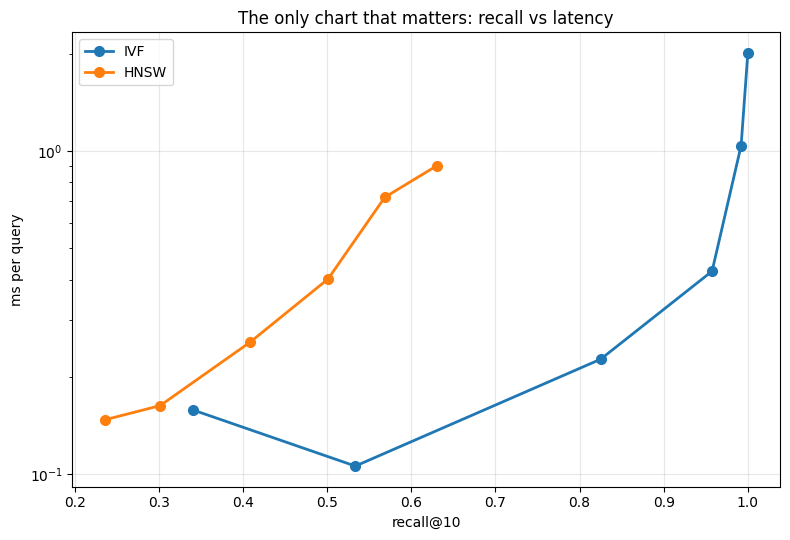

In [ ]:
# The curve everyone should look at before choosing anything.
pts = {"IVF": [], "HNSW": []}
for np_ in [1, 2, 5, 10, 20, 50]:
    index_ivf.nprobe = np_
    t0 = time.perf_counter()
    _, I = index_ivf.search(QUERIES, 10)
    pts["IVF"].append((recall_at_k(list(I), GT), (time.perf_counter() - t0) / len(QUERIES) * 1000))

for ef in [10, 16, 32, 64, 128, 256]:
    index_hnsw.hnsw.efSearch = ef
    t0 = time.perf_counter()
    _, I = index_hnsw.search(QUERIES, 10)
    pts["HNSW"].append((recall_at_k(list(I), GT), (time.perf_counter() - t0) / len(QUERIES) * 1000))

fig, ax = plt.subplots(figsize=(8, 5.5))
for name, vals in pts.items():
    r, t = zip(*vals)
    ax.plot(r, t, "o-", label=name, linewidth=2, markersize=7)
ax.set_xlabel("recall@10")
ax.set_ylabel("ms per query")
ax.set_yscale("log")
ax.set_title("The only chart that matters: recall vs latency")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
for spec in ["Flat", "IVF100,Flat", "IVF100,PQ8", "HNSW32", "IVF1024,PQ16"]:
    ix = faiss.index_factory(d, spec, faiss.METRIC_INNER_PRODUCT)
    print(f"{spec:<16} needs_training={not ix.is_trained}")

Flat             needs_training=False
IVF100,Flat      needs_training=True
IVF100,PQ8       needs_training=True
HNSW32           needs_training=False
IVF1024,PQ16     needs_training=True


*   `Flat` → §2, **exact**, no training
*   `IVF100,Flat` → §4, 100 clusters, full vectors inside
*   `IVF100,PQ8` → §4 + §6, 100 clusters, **8-byte compressed** vectors
*   `HNSW32` → §5, M=32
*   `IVF1024,PQ16` → the **billion-scale workhorse**

**Rough starting rules:**
*   **<1M vectors** → `Flat` or `HNSW32`.
*   **1M–10M** → `HNSW32` or `IVF4096,Flat`.
*   **>10M and RAM-constrained** → `IVF65536,PQ32` with re-ranking.

---

## 8. Chroma: a database, not just an index

Chroma is a *vector database* — it stores your documents, embeds them for you, attaches metadata, filters on it, and persists to disk without you writing a serialisation layer.

In [ ]:
import chromadb
client = chromadb.Client()                                  # in-memory
client = chromadb.PersistentClient(path="/tmp/chroma")    # on-disk, survives restarts
coll = client.get_or_create_collection(
    name="movies",
    metadata={"hnsw:space": "cosine"},
)
print(coll)

Collection(name=movies)


In [ ]:
docs = [    "A hacker discovers reality is a simulation and joins a rebellion.",    "A thief enters dreams to plant an idea in a target's mind.",    "Astronauts travel through a wormhole to find a new home for humanity.",    "Scientists clone dinosaurs for a theme park that goes wrong.",    "A coastal town is terrorised by a giant great white shark.",    "A crew of specialists plan an elaborate casino robbery.",    "Toys come to life when humans leave the room.",    "A clownfish crosses the ocean to rescue his captured son.",]
meta = [    {"title": "The Matrix",    "year": 1999, "genre": "scifi"},    {"title": "Inception",     "year": 2010, "genre": "scifi"},    {"title": "Interstellar",  "year": 2014, "genre": "scifi"},    {"title": "Jurassic Park", "year": 1993, "genre": "adventure"},    {"title": "Jaws",          "year": 1975, "genre": "thriller"},    {"title": "Ocean's Eleven","year": 2001, "genre": "heist"},    {"title": "Toy Story",     "year": 1995, "genre": "animation"},    {"title": "Finding Nemo",  "year": 2003, "genre": "animation"},]
coll.add(documents=docs, metadatas=meta, ids=[f"m{i}" for i in range(len(docs))])
print("count:", coll.count())

count: 8


Notice what did **not** happen: you never called an embedding model. Chroma embedded the text for you with a default model (`all-MiniLM-L6-v2`). Convenient — and a trap, because the default is silent. Always set it explicitly in real work.

In [ ]:
res = coll.query(
    query_texts=["movies about space travel"],
    n_results=3
)
for doc, m, dist in zip(res["documents"][0], res["metadatas"][0], res["distances"][0]):
    print(f"{dist:.3f}  {m['title']:<16} {doc[:44]}")

0.524  Interstellar     Astronauts travel through a wormhole to find
0.791  Jurassic Park    Scientists clone dinosaurs for a theme park 
0.826  Toy Story        Toys come to life when humans leave the room


> **Watch the direction of that number.** Chroma returns a **distance** — *lower is better*. FAISS's `IndexFlatIP` returns a *similarity* — *higher is better*. Mixing these up, or sorting the wrong way, is one of the most common bugs in real RAG code. Check which one you have, every time.

### Metadata filtering — the actual reason to choose a vector DB

In [ ]:
r1 = coll.query(query_texts=["exciting adventure"], n_results=3, where={"genre": "animation"})
print("only animation:")
for m in r1["metadatas"][0]:
    print("  ", m["title"], m["year"])

r2 = coll.query(query_texts=["exciting adventure"], n_results=3, where={"year": {"$gte": 2000}})
print("\nonly 2000 or later:")
for m in r2["metadatas"][0]:
    print("  ", m["title"], m["year"])

r3 = coll.query(
    query_texts=["a journey"],
    n_results=3,
    where={"$and": [{"genre": "scifi"}, {"year": {"$lt": 2012}}]}
)
print("\nscifi before 2012:")
for m in r3["metadatas"][0]:
    print("  ", m["title"], m["year"])

only animation:
   Toy Story 1995
   Finding Nemo 2003

only 2000 or later:
   Interstellar 2014
   Ocean's Eleven 2001
   Finding Nemo 2003

scifi before 2012:
   Inception 2010


This is genuinely hard to do yourself. Naive approaches both fail:

*   **Filter first, then search** — you'd have to build a separate index per filter combination.
*   **Search first, then filter** — ask for 10, filter down to 2, and you've silently lost results. Worse, if nothing in the top-10 matches the filter you return *nothing* despite matches existing deeper in the index.

Real systems do **filtered ANN**: the filter is applied *during* the graph traversal. Getting that right is most of what you're paying a vector DB for.

In [ ]:
# Full-text substring filter too, and update/delete with real semantics.
print(coll.query(
    query_texts=["ocean"],
    n_results=2,
    where_document={"$contains": "shark"}
)["metadatas"])
coll.update(
    ids=["m0"],
    metadatas=[
        {"title": "The Matrix", "year": 1999, "genre": "cyberpunk"}
    ]
)
coll.delete(ids=["m7"])
print("after delete, count:", coll.count())

[[{'title': 'Jaws', 'genre': 'thriller', 'year': 1975}]]
after delete, count: 7


In [ ]:
# Bring your own embeddings - the right way to do it in production.
from sentence_transformers import SentenceTransformer

t = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
coll2 = client.get_or_create_collection(
    "explicit", metadata={"hnsw:space": "cosine"}
)
coll2.add(
    documents=docs,
    embeddings=t.encode(docs, normalize_embeddings=True).tolist(),
    metadatas=meta,
    ids=[f"e{i}" for i in range(len(docs))],
)
out = coll2.query(
    query_embeddings=[t.encode("heist crew", normalize_embeddings=True).tolist()],
    n_results=2
)
print([m["title"] for m in out["metadatas"][0]])

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

["Ocean's Eleven", 'Interstellar']


---

## 6. FAISS vs Chroma, honestly

They are not really competitors. FAISS is an **index library**; Chroma is a **vector database** that uses an index library. Chroma's default backend is HNSW (via hnswlib).

| | FAISS | Chroma |
|---|---|---|
| **What it is** | ANN index library | Vector database |
| **Stores documents** | No — vectors + int ids only | Yes |
| **Metadata + filtering** | No | Yes, with `$gte`/`$and`/`$contains` |
| **Embeds text for you** | No | Yes (default model) |
| **Persistence** | You call `write_index` | Automatic with `PersistentClient` |
| **Index types** | Dozens (Flat, IVF, PQ, HNSW, OPQ, ...) | HNSW |
| **Tuning depth** | Very deep | Shallow (`hnsw:space`, `ef`, `M`) |
| **GPU** | Yes (`faiss-gpu`) | No |
| **Scale ceiling** | Billions | Low millions comfortably |
| **Concurrent writers** | You handle it | Handled |
| **Speed at equal recall** | Faster | Fine, with DB overhead |

**Use FAISS when:**

*   You're at 10M+ vectors.
*   You need PQ compression or GPU.
*   Latency is the binding constraint.
*   You already have a datastore for text and metadata and only need the ANN part.

**Use Chroma when:**

*   You're prototyping.
*   You need metadata filtering (very common — "only this user's documents", "only the last 90 days").
*   You want persistence and CRUD without writing it.
*   You're under a few million vectors.

**Use neither when:**

*   You have under ~50k vectors. Numpy brute force is simpler, exact, and often faster once you count index build time. Don't add a database to search 3,000 documents.